# Neural Network: Multiclass Classification

The one-hidden-layer network from `breast-cancer-neural-network.ipynb`, extended from two classes to four and applied to the [Vehicle Silhouettes](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29) dataset.

The task is to identify a vehicle type from 18 shape features extracted from its silhouette, captured at a range of angles. The four classes are a double-decker bus, a Chevrolet van, a Saab 9000, and an Opel Manta.

Two changes turn the binary network into a multiclass one:

- **Softmax replaces sigmoid** at the output. Instead of one unit producing a probability, four units produce a distribution that sums to one.
- **Categorical cross-entropy replaces binary cross-entropy** as the cost.

The hidden layer, backpropagation and gradient descent are otherwise unchanged. Everything is written in numpy; scikit-learn is used only for the split, scaling, label encoding and the final metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# for reproducibility
np.random.seed(777)

## 1. Loading and preprocessing the data

Labels arrive as strings, so a `LabelEncoder` maps them to integers for the metrics and a `OneHotEncoder` turns them into the 4-row target matrix the softmax output needs.

The split is 70/15/15 with seed 777, stratified so all four classes stay proportional. Features are standard-scaled with a scaler fit on the training split only, then transposed to (features x examples) to match the network's orientation.


In [3]:
df = pd.read_csv('Vehicles.csv', header=None) 

# Separate Features and Labels
X_raw = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

In [4]:
# Data Splitting: 70% Train, 15% Validation, 15% Test
# First split: 70% Train, 30% Temp
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X_raw, y_encoded, test_size=0.3, random_state=777, stratify=y_encoded)

# Second split: Split the 30% Temp into 50/50 (resulting in 15% Val, 15% Test)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split( X_temp, y_temp, test_size=0.5, random_state=777, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Reshape (features x examples)
X_train = X_train_scaled.T
X_val = X_val_scaled.T
X_test = X_test_scaled.T

# One-Hot Encode Labels for Output Layer
onehot_encoder = OneHotEncoder(sparse_output=False)
Y_train = onehot_encoder.fit_transform(y_train_raw.reshape(-1, 1)).T
Y_val = onehot_encoder.transform(y_val_raw.reshape(-1, 1)).T
Y_test = onehot_encoder.transform(y_test_raw.reshape(-1, 1)).T

print(f"Shapes -> X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"Shapes -> X_val:   {X_val.shape},   Y_val:   {Y_val.shape}")
print(f"Shapes -> X_test:  {X_test.shape},  Y_test:  {Y_test.shape}")

Shapes -> X_train: (18, 592), Y_train: (4, 592)
Shapes -> X_val:   (18, 127),   Y_val:   (4, 127)
Shapes -> X_test:  (18, 127),  Y_test:  (4, 127)


## 2. The network

The softmax is written with the standard stability trick: subtracting the row maximum before exponentiating, which stops `np.exp` overflowing on large scores without changing the result.

The backward pass turns out to be simpler than it looks. The gradient of categorical cross-entropy with respect to the output pre-activation collapses to `dZ2 = A2 - Y`, exactly the expression used in the binary network. The softmax Jacobian and the derivative of the log cancel each other, so the only substantive change is the shape of the output layer.


In [5]:
def softmax(z):
    """Compute softmax values for each set of scores in z."""
    e_z = np.exp(z - np.max(z, axis=0, keepdims=True)) 
    return e_z / np.sum(e_z, axis=0, keepdims=True)

def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(777)
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def forward_propagation(X, parameters):
    W1, b1, W2, b2 = parameters["W1"], parameters["b1"], parameters["W2"], parameters["b2"]
    
    # Hidden Layer (Tanh)
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    
    # Output Layer (Softmax)
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

def compute_cost(A2, Y):
    m = Y.shape[1]
    
    # Categorical Cross-Entropy Loss
    logprobs = np.multiply(Y, np.log(A2 + 1e-8)) # Epsilon for stability
    cost = -np.sum(logprobs) / m
    return float(np.squeeze(cost))

def backprop(parameters, cache, X, Y):
    m = X.shape[1]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    # Gradients of Output Layer: Softmax + Cross Entropy simplifies to A2 - Y
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    # Gradients of Hidden Layer: Tanh derivative: 1 - A1^2
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update_parameters(parameters, grads, learning_rate):
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]
    return parameters

In [6]:
def MultiClassModel(X_train, Y_train, X_val, Y_val, n_h=20, num_iterations=10000, learning_rate=0.01, print_cost=True):
    n_x = X_train.shape[0]
    n_y = Y_train.shape[0] # 4 classes
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    costs = []
    
    for i in range(num_iterations):
        # Forward Prop
        A2, cache = forward_propagation(X_train, parameters)
        
        cost = compute_cost(A2, Y_train)
        
        grads = backprop(parameters, cache, X_train, Y_train)
        
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if i % 1000 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after iteration {i}: {cost}")
                
    return parameters, costs

## 3. Training

Trained with 20 hidden units at a learning rate of 0.1 for 5,000 iterations.

A validation split was built above but is not used to tune anything here: the hyper-parameters are set by hand, and `X_val` and `Y_val` are passed to the model without being read.


Cost after iteration 0: 1.3860299339823485
Cost after iteration 1000: 0.35780679378536334


Cost after iteration 2000: 0.2756698909265571
Cost after iteration 3000: 0.20684821941362252


Cost after iteration 4000: 0.1573199373871156


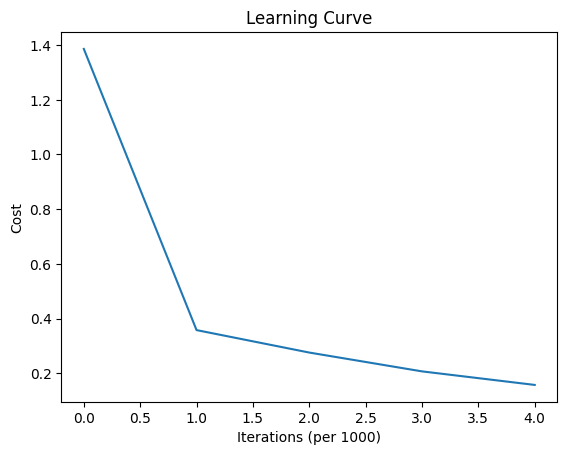

In [7]:
# n_h (Hidden Units) = 20, Learning Rate = 0.1, Iterations = 5000
parameters, costs = MultiClassModel(X_train, Y_train, X_val, Y_val, n_h=20, num_iterations=5000, learning_rate=0.1)

# Plot Cost Curve
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations (per 1000)')
plt.title('Learning Curve')
plt.show()

## 4. Evaluation on the test set

Accuracy, a per-class report and a confusion matrix, so errors can be attributed to specific classes instead of being averaged away.



Test Set Accuracy: 85.04%

Classification Report:

              precision    recall  f1-score   support

         bus       1.00      1.00      1.00        32
        opel       0.73      0.69      0.71        32
        saab       0.70      0.79      0.74        33
         van       1.00      0.93      0.97        30

    accuracy                           0.85       127
   macro avg       0.86      0.85      0.85       127
weighted avg       0.86      0.85      0.85       127



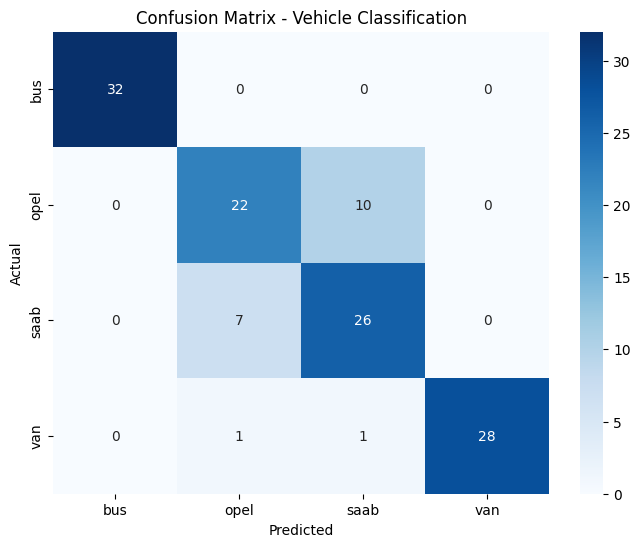

In [8]:
def predict_classes(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    return np.argmax(A2, axis=0) # Convert probas to class index (0, 1, 2, 3)

y_pred_test = predict_classes(parameters, X_test)

acc = accuracy_score(y_test_raw, y_pred_test)
print(f"\nTest Set Accuracy: {acc * 100:.2f}%")

target_names = label_encoder.inverse_transform([0, 1, 2, 3])
print("\nClassification Report:\n")
print(classification_report(y_test_raw, y_pred_test, target_names=target_names))

cm = confusion_matrix(y_test_raw, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Vehicle Classification')
plt.show()